Importing necessary libraries

In [641]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

Polynomial design matrix

In [642]:

def design_matrix(X, m):
    return np.hstack([X**i for i in range(m+1)])

OLS implementation in matrix notation

In [643]:
def ols_regression(X, y, m):
    X_poly = design_matrix(X, m)
    # Solve the normal equation: beta = (X^T * X)^-1 * X^T * y
    beta = np.linalg.inv(X_poly.T @ X_poly) @ (X_poly.T @ y)
    return beta

Function to make predictions on new data

In [644]:
def predict(X, beta, m):
    X_poly = design_matrix(X, m)
    return X_poly @ beta

TASK C
Function to calculate SSR and Coefficient of Determination

In [645]:
def calculate_ssr_r2(y_true, y_pred):
    ssr = np.sum((y_true - y_pred) ** 2)
    ssy = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ssr / ssy
    return ssr, r2

Fucntions to plot data

In [646]:
def plot_results(X_train, y_train, X_dev, y_dev, beta, degree, fit_type):
    # Sort the X_train and y_train for plotting
    sorted_idx = np.argsort(X_train.flatten())
    X_sorted = X_train.flatten()[sorted_idx]
    y_sorted = y_train[sorted_idx]
    
    # Create an evenly spaced range of X values for smooth line plotting
    X_range = np.linspace(X_sorted.min(), X_sorted.max(), 100).reshape(-1, 1)
    y_range = predict(X_range, beta, degree)

    plt.figure(figsize=(10, 6))
    
    # Scatter plot for the gold data (train + dev combined)
    plt.scatter(np.concatenate([X_train, X_dev]), np.concatenate([y_train, y_dev]),color='blue', label='Gold Data (Train + Dev)', alpha=0.5)
    
    # Line plot for the predicted data using the fitted model
    plt.plot(X_range, y_range, color='red', label=f'Degree {degree} - {fit_type}', linewidth=2)
    
    plt.title(f'Polynomial Regression (Degree {degree})')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.savefig(f"images/3_{fit_type}.png")

Reading traning and test data from CSV files

In [647]:
train_data = pd.read_csv(r"C:\Users\aksgu\Desktop\CS215_assignments\Assignment3\q3\train.csv")
test_data = pd.read_csv(r"C:\Users\aksgu\Desktop\CS215_assignments\Assignment3\q3\test.csv")
X_train = train_data['x'].values.reshape(-1, 1)
y_train = train_data['y'].values

X_test = test_data['x'].values.reshape(-1, 1)
ids = test_data['id'].values


TASK B
plotting underfit, bestfit and overfit regression based on prediction over dev set

best degree  6


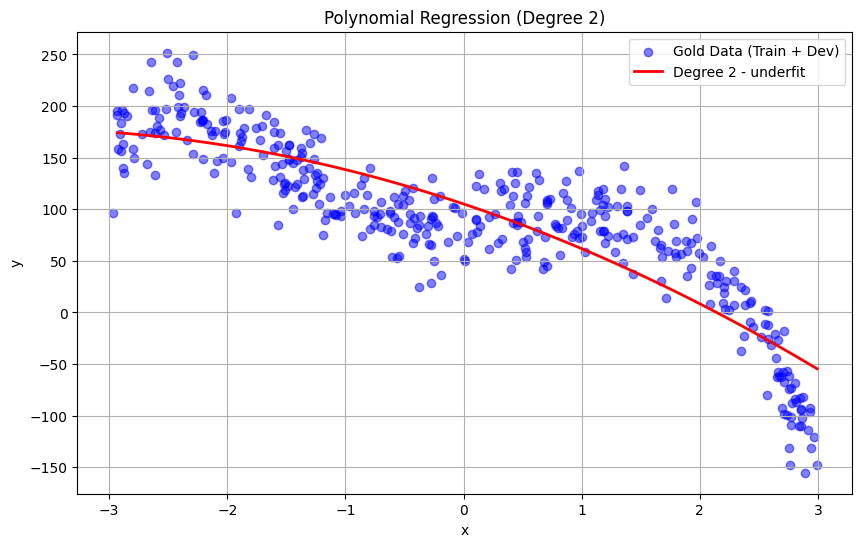

<Figure size 640x480 with 0 Axes>

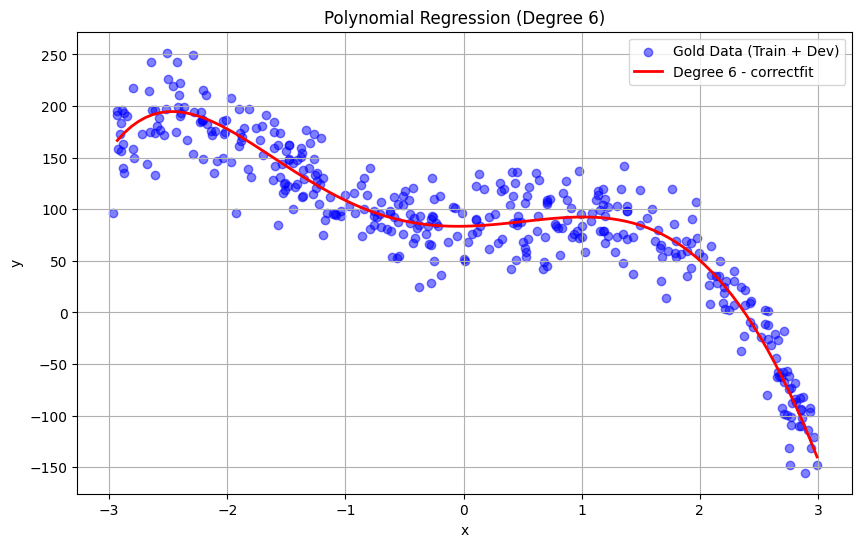

<Figure size 640x480 with 0 Axes>

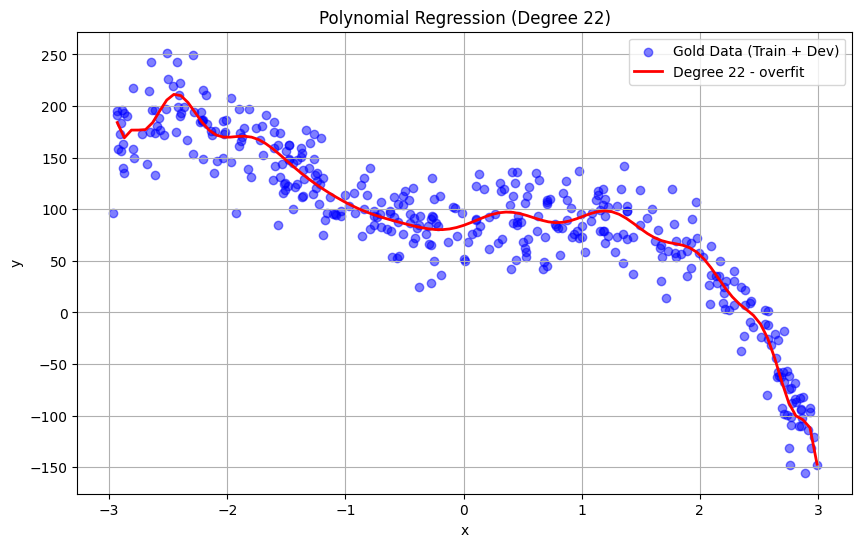

<Figure size 640x480 with 0 Axes>

In [648]:
# Split the training data into train (90%) and dev (10%) sets

x_y = np.column_stack((X_train,y_train))
n = x_y.shape[0]
split_index = int(0.9*n)
train , test = np.split(x_y,[split_index])
X_train  = train[:,0].reshape(-1,1) 
y_train = train[:,1]
X_dev = test[:,0].reshape(-1,1)
y_dev = test[:,1]

# Tracking for fit types
degrees_to_explore = range(1, 30)    #taking degrees in this range for wide exploration
best_degree = None
best_beta = None
lowest_ssr = float('inf')
error_dev=[]

# Explore polynomials of various degrees
for degree in degrees_to_explore: 
    # Fit model
    beta = ols_regression(X_train, y_train, degree)

    # Predict on training, dev, and test data
    y_pred_train = predict(X_train, beta, degree)
    y_pred_dev = predict(X_dev, beta, degree)

    # Calculate SSR and R2 for train and dev sets
    ssr_dev, r2_dev = calculate_ssr_r2(y_dev, y_pred_dev)
    error_dev.append(ssr_dev)
    
best_degree = np.argmin(np.array(error_dev))+1   #degree is index+1
print("best degree ", best_degree)


#for degrees [1,2,3] the model is underfit, for [4,5,6] the model is best fit, while higher degrees give overfit, one each relevant plot is as follows: 
plot_results(X_train, y_train, X_dev, y_dev, ols_regression(X_train, y_train,2), 2, "underfit")
plot_results(X_train, y_train, X_dev, y_dev,ols_regression(X_train, y_train, best_degree), best_degree, "correctfit")
plot_results(X_train, y_train, X_dev, y_dev, ols_regression(X_train, y_train,22), 22, "overfit")

TASK A
Finding beta for best fit model and plotting the regression

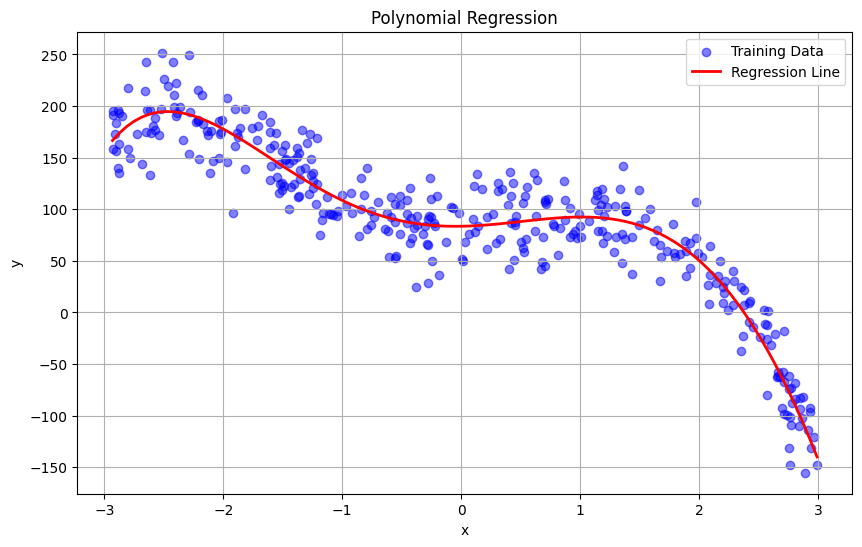

In [649]:

best_degree=6       #taken the best fit degree from above 
best_beta = ols_regression(X_train, y_train, best_degree)
    
# Predict on test set using the best model
y_pred_test = predict(X_test, best_beta, best_degree)

# Convert predictions to pandas dataframe for saving to CSV
df_predictions = pd.DataFrame({'id': ids, 'x': X_test.flatten(), 'y': y_pred_test})

# Save predictions to CSV file for the best model
df_predictions.to_csv("3_predictions.csv", index=False)

# Plotting
plt.figure(figsize=(10, 6))

# Scatter plot for training data
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.5)

# Plot regression line for training data
X_range = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
y_range = predict(X_range, best_beta, best_degree)
plt.plot(X_range, y_range, color='red', label='Regression Line', linewidth=2)

plt.title('Polynomial Regression')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()